# Dynamic Driving Strategy -- Driver Advisory Demo

Two pieces of the dynamic-strategy plan, both precompute-once / cheap-lookup-at-runtime
by design (see project discussion: the ESP never re-solves anything live, it only reads
a saved table):

1. **`digital_twin/driver_advisory.py`** -- "how far to your next action, and what speed
   should you be at." A glide-ceiling table (corners: natural coast-down only, no active
   braking -- that's reserved for the mandatory stops) built on the racing line.
2. **`digital_twin/dp_policy.py`** -- the DP backward-induction solve normally throws away
   every state's answer except the one path from a standing start. This saves the WHOLE
   table, so a live query from the driver's actual (position, speed) -- even a state the
   nominal path never visits -- is an O(1) lookup, compressed down to the same
   (v_target, v_coast) granularity GA/PSO/CMA-ES already use (never DP's raw per-10m
   trace -- that's too fine-grained for a driver to execute, see the design discussion).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# repo root: digital_twin modules use CWD-relative "data/..." paths
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

from digital_twin import driver_advisory as adv
from digital_twin import dp_policy

advisory = pd.read_csv("data/driver_advisory.csv")
policy = dp_policy.load_policy()
print(f"advisory table: {len(advisory)} points")
print(f"dp policy table: choice shape {policy['choice'].shape}, {len(policy['v_grid'])} velocity bins")

advisory table: 2936 points
dp policy table: choice shape (1450, 61), 61 velocity bins


## 1. Driver advisory: glide ceiling vs the old brake-everywhere ceiling

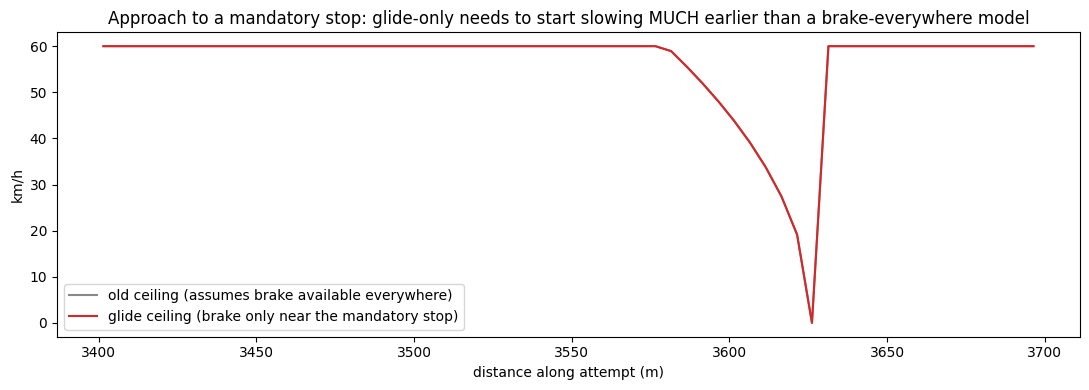

In [2]:
from digital_twin import track, simulate as sim_mod, weather as weather_mod

profile = track.build_racing_line_profile(save=False)
full_track = sim_mod.build_full_attempt_track(profile)
scenario = weather_mod.SCENARIOS["typical_january"]
old_ceiling = sim_mod.compute_speed_ceiling(full_track, cruise_kmh=60.0)

fig, ax = plt.subplots(figsize=(11, 4))
window = (advisory.s_m >= 3400) & (advisory.s_m <= 3700)
ax.plot(advisory.s_m[window], old_ceiling[window.to_numpy()], color="#888888",
        label="old ceiling (assumes brake available everywhere)")
ax.plot(advisory.s_m[window], advisory.glide_ceiling_kmh[window], color="#d62728",
        label="glide ceiling (brake only near the mandatory stop)")
ax.set_xlabel("distance along attempt (m)"); ax.set_ylabel("km/h")
ax.set_title("Approach to a mandatory stop: glide-only needs to start slowing MUCH earlier than a brake-everywhere model")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Driver advisory: example live queries

`next_action(advisory, s_now_m, v_now_kmh)` -- the O(1) lookup the ESP would call every
GPS tick. Corners never bind at legal strategy speeds (confirmed earlier: racing line's
tightest point needs 59.9 km/h minimum, well above anything the real strategy drives),
so in practice this almost always resolves to "distance to the next mandatory stop."

In [3]:
queries = [
    (500.0, 30.0, "mid-lap, normal speed"),
    (900.0, 40.0, "approaching stop-and-go 2, overspeed"),
    (2500.0, 45.0, "well before any stop, fast"),
]
rows = []
for s_now, v_now, label in queries:
    act = adv.next_action(advisory, s_now, v_now)
    rows.append({"scenario": label, "s_now_m": s_now, "v_now_kmh": v_now, **act})
pd.DataFrame(rows)

,scenario,s_now_m,v_now_kmh,distance_m,target_speed_kmh,action,s_m,latitude,longitude
0,"mid-lap, normal speed",500.0,30.0,442.352213,28.183596,glide,942.352213,25.491893,51.450589
1,"approaching stop-and-go 2, overspeed",900.0,40.0,32.216325,39.780418,glide,932.216325,25.491937,51.450500
2,"well before any stop, fast",2500.0,45.0,1101.539008,43.788790,glide,3601.539008,25.488218,51.450307


## 3. DP policy: proving the lookup works from an off-nominal state

The whole point: DP's backward induction computes the right answer for every
(distance, speed) cell, not just the ones the standing-start path visits. Query a state
the nominal path would never be in (much faster or much slower than planned) and confirm
the recommendation is still sane, not a lookup into empty/garbage table entries.

In [4]:
nominal_v_kmh = None
dp_tel_path = "data/simulated_telemetry_dp.csv"
if os.path.exists(dp_tel_path):
    dp_tel = pd.read_csv(dp_tel_path)
    nominal_v_kmh = dp_tel.set_index("s_m")["v_kmh"] if "v_kmh" in dp_tel.columns else None

test_states = [
    (500.0, 20.0, "on-nominal-ish: mid-lap, moderate speed"),
    (500.0, 45.0, "OFF-nominal: same position, far faster than the standing-start path ever is here"),
    (2500.0, 5.0, "OFF-nominal: crawling far slower than planned"),
]
rows = []
for s_now, v_now, label in test_states:
    rec = dp_policy.recommend_segment(policy, s_now, v_now)
    rows.append({
        "scenario": label, "s_now_m": s_now, "v_now_kmh": v_now,
        "v_target_kmh": round(rec["v_target_kmh"], 1), "v_coast_kmh": round(rec["v_coast_kmh"], 1),
        "window": f"{rec['s_start_m']:.0f}-{rec['s_end_m']:.0f}m",
    })
pd.DataFrame(rows)

,scenario,s_now_m,v_now_kmh,v_target_kmh,v_coast_kmh,window
0,"on-nominal-ish: mid-lap, moderate speed",500.0,20.0,19.8,13.0,500-621m
1,"OFF-nominal: same position, far faster than th...",500.0,45.0,45.0,35.5,500-621m
2,OFF-nominal: crawling far slower than planned,2500.0,5.0,24.3,24.3,2502-2622m


## 4. Putting them together: one combined recommendation

The intended flow: `dp_policy.recommend_segment()` answers "what's the best target for
the upcoming stretch, given where the car actually is" (the backend, state-aware
replanning piece); `driver_advisory.next_action()` answers "how far until you need to
act, and to what speed" (the always-on turn-by-turn instruction). Neither ever exposes
DP's raw per-point trace or a live solve to the driver -- both are precomputed tables,
read at query time.

In [5]:
def combined_recommendation(s_now_m, v_now_kmh):
    seg = dp_policy.recommend_segment(policy, s_now_m, v_now_kmh)
    action = adv.next_action(advisory, s_now_m, v_now_kmh)
    return {
        "segment_v_target_kmh": round(seg["v_target_kmh"], 1),
        "segment_v_coast_kmh": round(seg["v_coast_kmh"], 1),
        "next_action_distance_m": None if action["distance_m"] is None else round(action["distance_m"], 1),
        "next_action_target_kmh": None if action["target_speed_kmh"] is None else round(action["target_speed_kmh"], 1),
        "next_action_type": action["action"],
    }

for s_now, v_now, label in test_states:
    print(f"{label}\n  s={s_now}m v={v_now}km/h -> {combined_recommendation(s_now, v_now)}\n")

on-nominal-ish: mid-lap, moderate speed
  s=500.0m v=20.0km/h -> {'segment_v_target_kmh': 19.8, 'segment_v_coast_kmh': 13.0, 'next_action_distance_m': 452.6, 'next_action_target_kmh': 0.0, 'next_action_type': 'brake'}

OFF-nominal: same position, far faster than the standing-start path ever is here
  s=500.0m v=45.0km/h -> {'segment_v_target_kmh': 45.0, 'segment_v_coast_kmh': 35.5, 'next_action_distance_m': 427.2, 'next_action_target_kmh': 44.4, 'next_action_type': 'glide'}

OFF-nominal: crawling far slower than planned
  s=2500.0m v=5.0km/h -> {'segment_v_target_kmh': 24.3, 'segment_v_coast_kmh': 24.3, 'next_action_distance_m': 1126.2, 'next_action_target_kmh': 0.0, 'next_action_type': 'brake'}



## Status

- **Built and validated**: `driver_advisory.py` (glide/brake ceiling, corners never bind
  at legal speeds, stop-approach kinematics confirmed against BRAKE_MAX_MS2), `dp_policy.py`
  (full backward-induction table saved instead of discarded, segment-compression robust to
  single-point transients via a percentile instead of a raw min).
- **Not built**: the third piece from the original plan -- a small precomputed family of
  wider racing lines as a safety fallback for corner-entry overspeed. Lower priority (corners
  don't bind at any realistic strategy speed today) and not started.
- **Depends on**: `data/racing_line.csv`, `data/dp_policy.npz`, `data/driver_advisory.csv` --
  all regenerate via `python -m digital_twin.racing_line` / `dp_policy` / `driver_advisory`
  whenever the track, vehicle config, or motor changes.